In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Danso Emmanuel Effah\OneDrive\Desktop\DATA ANALYSIS\Projects\India Project\Stock Prices Data Set.csv")

## Cleaning column names
df.columns = df.columns.str.strip()

## Converting date column to datetime
df['date'] = pd.to_datetime(df['date'])

## Sortting by date 
df = df.sort_values('date')

# Setting date as index
df.set_index('date', inplace=True)

print(df.head())

           symbol   open   high     low  close   volume
date                                                   
2014-01-02    AAL  25.07  25.82  25.060  25.36  8998943
2014-01-02   NVDA  15.92  15.98  15.720  15.86  6502296
2014-01-02    NUE  53.29  53.38  52.510  52.73  1611326
2014-01-02   NTRS  61.76  61.95  60.665  60.89  1011050
2014-01-02   NTAP  41.01  41.01  40.415  40.42  2427140


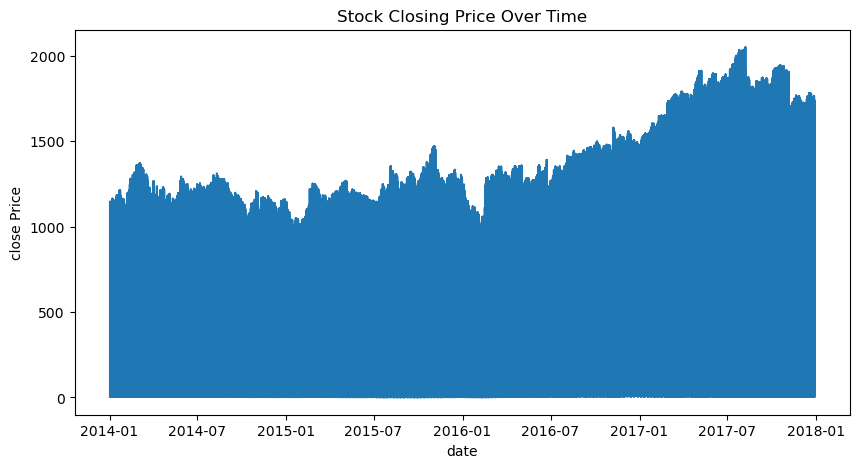

In [5]:
### drawing time series
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("date")
plt.ylabel("close Price")
plt.show()

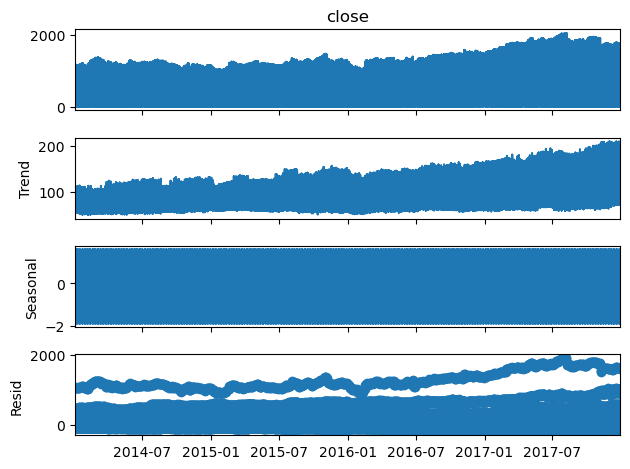

In [6]:
## decomposing series trends
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['close'], model='additive', period=30)

decomposition.plot()
plt.show()

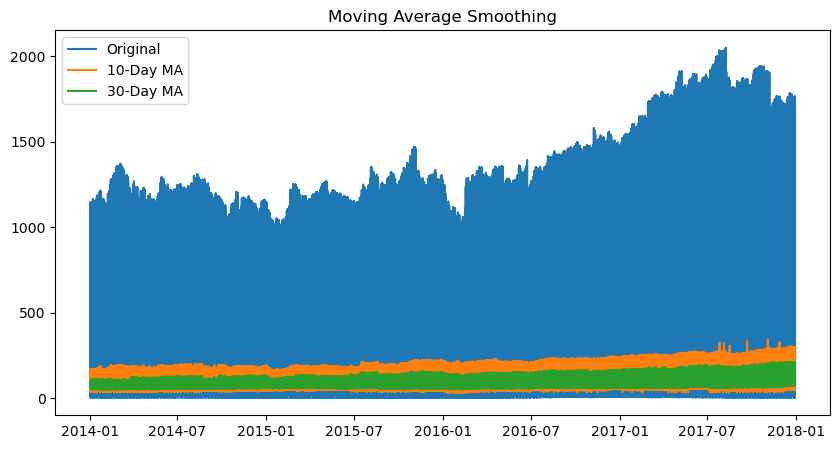

In [8]:
## Moving Average Smoothing
df['MA_10'] = df['close'].rolling(window=10).mean()
df['MA_30'] = df['close'].rolling(window=30).mean()

plt.figure(figsize=(10,5))
plt.plot(df['close'], label='Original')
plt.plot(df['MA_10'], label='10-Day MA')
plt.plot(df['MA_30'], label='30-Day MA')
plt.legend()
plt.title("Moving Average Smoothing")
plt.show()